🔍 Found 3 TensorBoard event files.

📊 Top tags (stripped; Ray prefixes removed):
  3 files: num_training_step_calls_per_iteration
  3 files: num_env_steps_sampled_lifetime
  3 files: done
  3 files: time_this_iter_s
  3 files: time_since_restore
  3 files: iterations_since_restore
  3 files: timers/training_iteration
  3 files: timers/restore_env_runners
  3 files: timers/training_step
  3 files: timers/env_runner_sampling_timer
  3 files: timers/learner_update_timer
  3 files: timers/synch_weights
  3 files: env_runners/env_reset_timer
  3 files: env_runners/episode_return_max
  3 files: env_runners/num_env_steps_sampled
  3 files: env_runners/env_step_timer
  3 files: env_runners/sample
  3 files: env_runners/episode_duration_sec_mean
  3 files: env_runners/episode_return_mean
  3 files: env_runners/weights_seq_no
  3 files: env_runners/episode_return_min
  3 files: env_runners/num_episodes_lifetime
  3 files: env_runners/num_episodes
  3 files: env_runners/num_env_steps_sampled_life

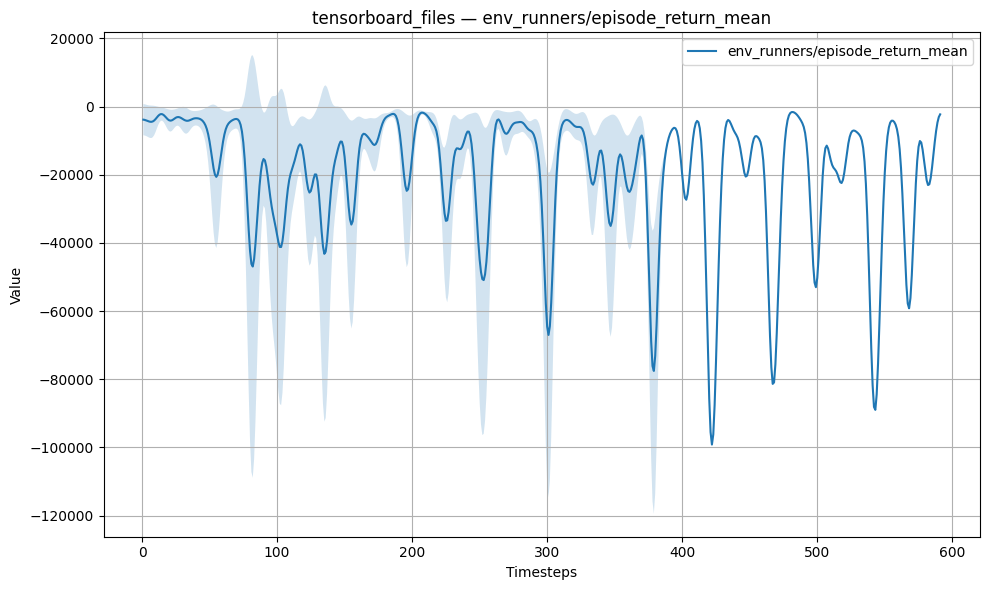

In [7]:
# --- RLlib/Ray-friendly helpers ---

import os, re, glob
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.python.summary.summary_iterator import summary_iterator
from scipy.ndimage import gaussian_filter1d

# ---------- event reading ----------
def get_all_tensorboard_event_files(base_dir):
    files = glob.glob(os.path.join(base_dir, "events.out.tfevents.*"))
    files += glob.glob(os.path.join(base_dir, "**", "events.out.tfevents.*"), recursive=True)
    seen, uniq = set(), []
    for f in files:
        if f not in seen:
            uniq.append(f); seen.add(f)
    return uniq

def safe_iter_events(path):
    try:
        for e in summary_iterator(path):
            yield e
    except Exception as ex:
        print(f"⚠️ Skipping {path} (read error: {ex})")

# ---------- tag utilities ----------
RAY_PREFIX = re.compile(r"^(ray/(tune|train|rllib)/)")
def strip_ray_prefix(tag: str) -> str:
    # remove leading "ray/tune/" or "ray/train/" etc. for matching
    return RAY_PREFIX.sub("", tag)

def tag_frequency(event_files, max_per_file=500):
    """Count distinct tags across files (once per file), and also keep a 'stripped' view for Ray."""
    raw = Counter()
    stripped = Counter()
    for path in event_files:
        seen_raw = set()
        seen_stripped = set()
        steps_seen = 0
        for e in safe_iter_events(path):
            for v in e.summary.value:
                t = v.tag
                ts = strip_ray_prefix(t)
                if t not in seen_raw:
                    raw[t] += 1; seen_raw.add(t)
                if ts not in seen_stripped:
                    stripped[ts] += 1; seen_stripped.add(ts)
            steps_seen += 1
            if steps_seen >= max_per_file:
                break
    return raw, stripped

# Common RLlib reward/return tags (stripped form, i.e., without ray/tune/...)
REWARD_TAG_PREFERENCE = [
    "evaluation/episode_reward_mean",
    "episode_reward_mean",
    "rollout/episode_reward_mean",
    "episode_return_mean",
    "evaluation/episode_return_mean",
    "train/episode_reward_mean",
    "train/mean_reward",
    "charts/episode_reward_mean",
]
REWARD_REGEX = re.compile(
    r"(episode|ep).*(reward|return).*(mean|avg)|"
    r"(reward|return).*(episode|ep).*(mean|avg)",
    re.IGNORECASE,
)

# X-axis priorities for RLlib/Ray (stripped form)
X_AXIS_TAG_PREFERENCE = [
    "timesteps_total",
    "env_steps_sampled",
    "env_steps_trained",
    "training_iteration",
    "episodes_total",
]

def choose_reward_tag(available_stripped_tags: set) -> str | None:
    for t in REWARD_TAG_PREFERENCE:
        if t in available_stripped_tags:
            return t
    candidates = [t for t in available_stripped_tags if REWARD_REGEX.search(t)]
    if candidates:
        candidates.sort(key=lambda s: (len(s), s))
        return candidates[0]
    return None

def choose_x_axis_tag(available_stripped_tags: set) -> str | None:
    for t in X_AXIS_TAG_PREFERENCE:
        if t in available_stripped_tags:
            return t
    return None  # fallback to TF internal step

# ---------- grouping ----------
def infer_group_from_path(path):
    """
    For single-folder setups, prefer parent directory as group; otherwise use a short token from filename.
    This avoids groups like 'events.out.tfevents.*.host'.
    """
    base = os.path.basename(path).lower()
    parent = os.path.basename(os.path.dirname(path)).lower()
    if parent and not parent.startswith("events.out.tfevents"):
        return parent
    m = re.match(r"([a-z0-9]+)", base)
    return m.group(1) if m else "unknown"

def group_by_inferred_name(event_paths):
    groups = defaultdict(list)
    for p in event_paths:
        groups[infer_group_from_path(p)].append(p)
    return groups

# ---------- extraction ----------
def extract_series(event_paths, y_tag, x_tag=None):
    """
    Aggregate a scalar y_tag across multiple runs.
    If x_tag is provided, align using TF 'step' and return x-values from that tag; else use 'step' on the x-axis.
    Returns (xs_sorted, mean_y, std_y).
    Tags should be provided in *stripped* form; we will accept either stripped or with ray/tune prefix.
    """
    # Accept both exact stripped tag and any variant prefixed with ray/tune/...
    def matches(tag, wanted):
        return strip_ray_prefix(tag) == wanted

    # Collect per-step values across runs
    x_by_step_all_runs = defaultdict(list) if x_tag else None
    y_by_step = defaultdict(list)

    for path in event_paths:
        x_by_step = {}  # step -> x
        y_by_step_run = {}  # step -> y
        for e in safe_iter_events(path):
            # read all values for this step
            for v in e.summary.value:
                t = v.tag
                if x_tag and matches(t, x_tag):
                    x_by_step[e.step] = float(v.simple_value)
                if matches(t, y_tag):
                    y_by_step_run[e.step] = float(v.simple_value)
        # merge run data
        if x_tag:
            for s, xv in x_by_step.items():
                x_by_step_all_runs[s].append(xv)
        for s, yv in y_by_step_run.items():
            y_by_step[s].append(yv)

    # Determine x for each step
    steps = sorted(y_by_step.keys())
    if x_tag:
        # use mean x across runs for each step (if missing, fallback to step)
        xs = [np.mean(x_by_step_all_runs[s]) if s in x_by_step_all_runs else float(s) for s in steps]
    else:
        xs = [float(s) for s in steps]

    means = [np.mean(y_by_step[s]) for s in steps]
    stds  = [np.std(y_by_step[s])  for s in steps]
    # sort by x
    order = np.argsort(xs)
    xs = list(np.array(xs)[order])
    means = list(np.array(means)[order])
    stds = list(np.array(stds)[order])
    return xs, means, stds

# ---------- plotting ----------
def plot_smoothed_line(xs, means, stds, label="metric", title="", normalize=False, sigma=3):
    plt.figure(figsize=(10, 6))
    means = np.array(means); stds = np.array(stds); xs = np.array(xs)
    sm_m = gaussian_filter1d(means, sigma=sigma)
    sm_s = gaussian_filter1d(stds,  sigma=sigma)
    if normalize:
        mn, mx = sm_m.min(), sm_m.max()
        rng = (mx - mn) if mx > mn else 1.0
        sm_m = (sm_m - mn) / rng
        sm_s = sm_s / rng
        lower = np.clip(sm_m - sm_s, 0, 1); upper = np.clip(sm_m + sm_s, 0, 1)
        plt.ylabel("Normalized value")
    else:
        lower, upper = sm_m - sm_s, sm_m + sm_s
        plt.ylabel("Value")
    plt.plot(xs, sm_m, label=label)
    plt.fill_between(xs, lower, upper, alpha=0.2)
    plt.xlabel("Timesteps" if (len(xs) and xs[0] != 0 and max(xs) > max(range(len(xs)))) else "Step")
    plt.title(title); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ---------- driver (example usage) ----------
if __name__ == "__main__":
    base_dir = "./tensorboard_files"
    event_files = get_all_tensorboard_event_files(base_dir)
    print(f"🔍 Found {len(event_files)} TensorBoard event files.")
    if not event_files:
        raise SystemExit("No event files found.")

    raw_freq, stripped_freq = tag_frequency(event_files, max_per_file=600)

    print("\n📊 Top tags (stripped; Ray prefixes removed):")
    for tag, cnt in stripped_freq.most_common(40):
        print(f"{cnt:3d} files: {tag}")

    # Pick tags the RLlib way
    y_tag = choose_reward_tag(set(stripped_freq.keys()))
    if y_tag is None:
        raise SystemExit("Could not auto-find an RLlib reward tag. Pick one from the list above.")
    x_tag = choose_x_axis_tag(set(stripped_freq.keys()))  # may be None; then TF step is used

    print(f"\n✅ Using Y tag: {y_tag}")
    print(f"✅ Using X tag: {x_tag if x_tag else 'TensorBoard step'}")

    groups = group_by_inferred_name(event_files)
    for grp, paths in groups.items():
        xs, means, stds = extract_series(paths, y_tag=y_tag, x_tag=x_tag)
        if not xs:
            print(f"⚠️ No '{y_tag}' data for group '{grp}'.")
            continue
        title = f"{grp} — {y_tag}" + (f" vs {x_tag}" if x_tag else "")
        plot_smoothed_line(xs, means, stds, label=y_tag, title=title, normalize=False, sigma=3)


In [2]:
# -*- coding: utf-8 -*-
# --- Plot por pasta de experimento (RLlib/Ray-friendly) ---

import os
import re
import glob
from collections import defaultdict, Counter
from typing import Optional, Set

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.python.summary.summary_iterator import summary_iterator
from scipy.ndimage import gaussian_filter1d

# ---------- leitura de eventos ----------
def get_all_tensorboard_event_files(base_dir):
    files = glob.glob(os.path.join(base_dir, "events.out.tfevents.*"))
    files += glob.glob(os.path.join(base_dir, "**", "events.out.tfevents.*"), recursive=True)
    seen, uniq = set(), []
    for f in files:
        if f not in seen:
            uniq.append(f); seen.add(f)
    return uniq

def get_event_files_in_dir(d):
    return sorted(glob.glob(os.path.join(d, "**", "events.out.tfevents.*"), recursive=True))

def safe_iter_events(path):
    try:
        for e in summary_iterator(path):
            yield e
    except Exception as ex:
        print(f"⚠️  Ignorando {path} (erro de leitura: {ex})")

# ---------- utilitários de tags ----------
RAY_PREFIX = re.compile(r"^(ray/(tune|train|rllib)/)")
def strip_ray_prefix(tag: str) -> str:
    # remove "ray/tune/" ou "ray/train/" etc. para facilitar matching
    return RAY_PREFIX.sub("", tag)

def tag_frequency(event_files, max_per_file=500):
    """Conta tags distintas (uma vez por arquivo) e também a versão 'stripped' sem prefixos do Ray."""
    raw = Counter()
    stripped = Counter()
    for path in event_files:
        seen_raw = set()
        seen_stripped = set()
        steps_seen = 0
        for e in safe_iter_events(path):
            for v in e.summary.value:
                t = v.tag
                ts = strip_ray_prefix(t)
                if t not in seen_raw:
                    raw[t] += 1; seen_raw.add(t)
                if ts not in seen_stripped:
                    stripped[ts] += 1; seen_stripped.add(ts)
            steps_seen += 1
            if steps_seen >= max_per_file:
                break
    return raw, stripped

# Tags comuns do RLlib para recompensa/retorno (forma "stripped")
REWARD_TAG_PREFERENCE = [
    "evaluation/episode_reward_mean",
    "episode_reward_mean",
    "rollout/episode_reward_mean",
    "episode_return_mean",
    "evaluation/episode_return_mean",
    "train/episode_reward_mean",
    "train/mean_reward",
    "charts/episode_reward_mean",
]
REWARD_REGEX = re.compile(
    r"(episode|ep).*(reward|return).*(mean|avg)|"
    r"(reward|return).*(episode|ep).*(mean|avg)",
    re.IGNORECASE,
)

# Prioridades para eixo X (forma "stripped")
X_AXIS_TAG_PREFERENCE = [
    "timesteps_total",
    "env_steps_sampled",
    "env_steps_trained",
    "training_iteration",
    "episodes_total",
]

def choose_reward_tag(available_stripped_tags: Set[str]) -> Optional[str]:
    for t in REWARD_TAG_PREFERENCE:
        if t in available_stripped_tags:
            return t
    candidates = [t for t in available_stripped_tags if REWARD_REGEX.search(t)]
    if candidates:
        candidates.sort(key=lambda s: (len(s), s))
        return candidates[0]
    return None

def choose_x_axis_tag(available_stripped_tags: Set[str]) -> Optional[str]:
    for t in X_AXIS_TAG_PREFERENCE:
        if t in available_stripped_tags:
            return t
    return None  # fallback: passo interno do TensorBoard

# ---------- extração ----------
def extract_series(event_paths, y_tag, x_tag=None):
    """
    Agrega um escalar y_tag em múltiplos runs.
    Se x_tag for fornecida, alinha usando o 'step' do TF e retorna x a partir dessa tag; senão usa 'step'.
    Retorna (xs_sorted, mean_y, std_y).
    As tags devem ser fornecidas em forma *stripped* (sem prefixo ray/*),
    mas o matching aceita ambas as formas.
    """
    def matches(tag, wanted):
        return strip_ray_prefix(tag) == wanted

    x_by_step_all_runs = defaultdict(list) if x_tag else None
    y_by_step = defaultdict(list)

    for path in event_paths:
        x_by_step = {}       # step -> x
        y_by_step_run = {}   # step -> y
        for e in safe_iter_events(path):
            for v in e.summary.value:
                t = v.tag
                if x_tag and matches(t, x_tag):
                    x_by_step[e.step] = float(v.simple_value)
                if matches(t, y_tag):
                    y_by_step_run[e.step] = float(v.simple_value)
        if x_tag:
            for s, xv in x_by_step.items():
                x_by_step_all_runs[s].append(xv)
        for s, yv in y_by_step_run.items():
            y_by_step[s].append(yv)

    steps = sorted(y_by_step.keys())
    if not steps:
        return [], [], []
    if x_tag:
        xs = [np.mean(x_by_step_all_runs[s]) if s in x_by_step_all_runs else float(s) for s in steps]
    else:
        xs = [float(s) for s in steps]

    means = [np.mean(y_by_step[s]) for s in steps]
    stds  = [np.std(y_by_step[s])  for s in steps]
    order = np.argsort(xs)
    xs = list(np.array(xs)[order])
    means = list(np.array(means)[order])
    stds = list(np.array(stds)[order])
    return xs, means, stds

# ---------- plotagem ----------
def plot_smoothed_line(xs, means, stds, label="metric", title="", normalize=False, sigma=3, save_path=None):
    plt.figure(figsize=(10, 6))
    means = np.array(means); stds = np.array(stds); xs = np.array(xs)
    # Suaviza só se houver pontos suficientes
    sm_m = gaussian_filter1d(means, sigma=sigma) if len(means) >= 3 else means
    sm_s = gaussian_filter1d(stds,  sigma=sigma) if len(stds)  >= 3 else stds
    if normalize:
        mn, mx = sm_m.min(), sm_m.max()
        rng = (mx - mn) if mx > mn else 1.0
        sm_m = (sm_m - mn) / rng
        sm_s = sm_s / rng
        lower = np.clip(sm_m - sm_s, 0, 1); upper = np.clip(sm_m + sm_s, 0, 1)
        plt.ylabel("Normalized value")
    else:
        lower, upper = sm_m - sm_s, sm_m + sm_s
        plt.ylabel("Value")
    plt.plot(xs, sm_m, label=label)
    plt.fill_between(xs, lower, upper, alpha=0.2)
    xlabel = "Timesteps"
    if not len(xs) or (xs[0] == 0 and max(xs, default=0) <= len(xs)):
        xlabel = "Step"
    plt.xlabel(xlabel)
    plt.title(title); plt.legend(); plt.grid(True); plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150)
        print(f"💾 Salvo: {save_path}")
        plt.close()
    else:
        plt.show()

# ---------- driver: uma figura por subpasta ----------
if __name__ == "__main__":
    # >>> ALTERE AQUI <<<
    # Ex.: base_dir = "/mnt/ssd1/rafael/graph-exploration/exp_results_copy"
    base_dir = "./exp_results_copy"

    # Subpastas imediatas (experimentos)
    subdirs = [os.path.join(base_dir, d) for d in os.listdir(base_dir)
               if os.path.isdir(os.path.join(base_dir, d))]

    # Se também houver eventos diretamente no base_dir, inclui o próprio base_dir
    consider = [base_dir] + subdirs

    for folder in consider:
        event_files = get_event_files_in_dir(folder)
        if not event_files:
            # print(f"… Sem eventos em {folder}")
            continue

        # Descoberta de tags por pasta (robusto quando variam entre exp.)
        _, stripped_freq = tag_frequency(event_files, max_per_file=800)
        available = set(stripped_freq.keys())
        y_tag = choose_reward_tag(available)
        x_tag = choose_x_axis_tag(available)

        if y_tag is None:
            print(f"⚠️  {os.path.basename(folder)}: não encontrei tag de recompensa/retorno. Ignorando.")
            continue

        xs, means, stds = extract_series(event_files, y_tag=y_tag, x_tag=x_tag)
        if not xs:
            print(f"⚠️  {os.path.basename(folder)}: sem dados para '{y_tag}'. Ignorando.")
            continue

        exp_name = os.path.basename(folder.rstrip("/"))
        title = f"{exp_name} — {y_tag}" + (f" vs {x_tag}" if x_tag else "")
        fn = f"{exp_name}__{y_tag.replace('/','_')}" + (f"__{x_tag.replace('/','_')}" if x_tag else "__step") + ".png"
        save_path = os.path.join(folder, fn)

        plot_smoothed_line(
            xs, means, stds,
            label=y_tag,
            title=title,
            normalize=False,
            sigma=3,
            save_path=save_path
        )

    print("✅ Concluído.")


FileNotFoundError: [Errno 2] No such file or directory: './exp_results_copy'